               Model           MAE          RMSE  R2 Score
0  Linear Regression  50670.738241  70060.521845  0.625424
1      Random Forest  31631.018675  49008.789216  0.816709


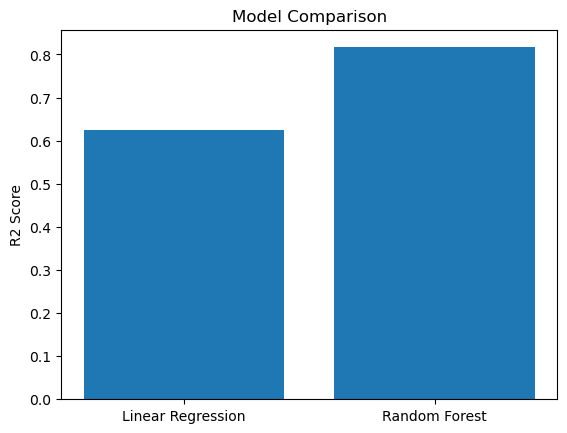

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load data
df = pd.read_csv("housing.csv")

df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models used are linear regression and randomforestregressor
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    results.append([
        name,
        mean_absolute_error(y_test, pred),
        np.sqrt(mean_squared_error(y_test, pred)),
        r2_score(y_test, pred)
    ])

results = pd.DataFrame(
    results,
    columns=["Model", "MAE", "RMSE", "R2 Score"]
)

print(results)

# Comparison graph
plt.bar(results["Model"], results["R2 Score"])
plt.title("Model Comparison")
plt.ylabel("R2 Score")
plt.show()